# Canonical Ordering

This notebook serves as an example for plotting canonical tree from CPM embedding. For more details, please refer to  Section 2.4 in our [paper](https://doi.org/10.1101/2025.08.22.671789). 

We analyze dataset from [Paul et al. (2015)](#references), comprising scRNA-seq profiles of approximately
2,730 mouse bone marrow-derived myeloid progenitor cells, including common myeloid progenitors (CMP), granulocyte-monocyte progenitors (GMP), and megakaryocyte–erythroid progenitor (MEP). It captures transcriptional heterogeneity across these cell types, revealing lineagespecific gene expression patterns. This dataset is widely used to study hematopoietic differentiation, transcriptional priming, and to benchmark single-cell analysis methods. The processed
dataset was obtained from [Klimovskaia et al., (2020)](#references). The trained model and the config files for CPM can be found [here](./results/mice_hematopoeisis). We directly load the embedding for this example.

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from helpers.poincare_maps import *
from model.poincare_loss import poincare_root, poincare_translation
from helpers.coldict import color_dict_paul

data_file = "./results/mice_hematopoeisis/Paul.csv"
embed_file = "./results/mice_hematopoeisis/Paul_emb.csv"
root = "root"

embedding = pd.read_csv(embed_file, sep=',', header=None).to_numpy()
dataset = pd.read_csv(data_file, sep=',')

target_cells = dataset.iloc[:, -1]
data = dataset.iloc[:, :-1]

# align root
root_hat = poincare_root(root, target_cells.astype(str).to_numpy(), data.to_numpy())
poincare_coord_new = poincare_translation(-embedding[root_hat, :], embedding)

Next, we calculate the distances from root and angular separation between the samples based on CPM embedding, and plot these. Distances and angular relationships in the
CPM embedding faithfully preserve the canonical haematopoietic
hierarchy, with particularly accurate reconstruction of the
myeloid branch comprising basophils, neutrophils, monocytes, and eosinophils. 

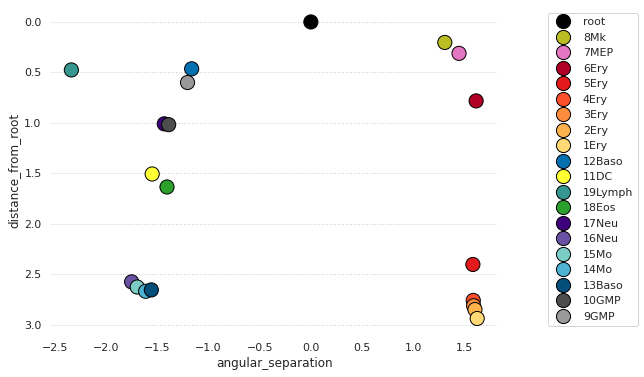

In [10]:
%matplotlib inline

model = PoincareMaps(poincare_coord_new)

model.get_distances()
angles = np.arctan2(poincare_coord_new[:, 1], poincare_coord_new[:, 0])

# organise data for plotting
df_to_plot = pd.DataFrame()
df_to_plot["distance_from_root"] = model.distances[model.iroot]
df_to_plot["target_cells"] = target_cells.values
df_to_plot["angular_separation"] = angles

# calculate median distance for each cell type and sort the distances
median_distances = df_to_plot.groupby(["target_cells"]).median()
median_distances = median_distances.reset_index()
custom_order = ["root", "8Mk", "7MEP", "6Ery", "5Ery", "4Ery", "3Ery", "2Ery", "1Ery",
                 "12Baso", "11DC", "19Lymph", "18Eos", "17Neu", "16Neu", "15Mo", "14Mo", 
                "13Baso", "10GMP", "9GMP"]
median_distances["target_cells"] = pd.Categorical(median_distances['target_cells'], 
                                                  categories=custom_order, ordered=True)
median_distances = median_distances.sort_values(by="target_cells")

fig, ax =plt.subplots(figsize=(8,6))
sns.scatterplot(data=median_distances, x="angular_separation", y="distance_from_root", 
                hue="target_cells", palette=color_dict_paul, ax=ax, s=200,
                edgecolor="black", linewidth=1)
ax.invert_yaxis()
ax.grid(axis='y', linestyle='dotted')
sns.despine(left=True, bottom=True)
ax.set_facecolor("white")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.1, 1), title=None)

<a id="references"></a>

## References

1. Franziska Paul, Yaara Arkin, Amir Giladi, Diego A Jaitin, Eran Kenigsberg, Hadas KerenShaul, Diana Winter, Daniel Lara-Astiaso, Miriam Gury, Assaf Weiner, et al. Transcriptional
heterogeneity and lineage commitment in myeloid progenitors. Cell, 163(7):1663–1677, 2015.

2. Anna Klimovskaia, David Lopez-Paz, Léon Bottou, and Maximilian Nickel. Poincaré maps for
analyzing complex hierarchies in single-cell data. Nature communications, 11(1):2966, 2020